<a href="https://colab.research.google.com/github/kjahan/duplicate_detection/blob/main/notebooks/images/pytorch_vision_vgg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### This notebook is optionally accelerated with a GPU runtime.
### If you would like to use this acceleration, please select the menu option "Runtime" -> "Change runtime type", select "Hardware Accelerator" -> "GPU" and click "SAVE"

----------------------------------------------------------------------

# vgg-nets

*Author: Pytorch Team*

**Award winning ConvNets from 2014 ImageNet ILSVRC challenge**

<img src="https://pytorch.org/assets/images/vgg.png" alt="alt" width="50%"/>

In [110]:
import torch
#model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True)
# or any of these variants
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg11_bn', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg13', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg13_bn', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg16', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg16_bn', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg19', pretrained=True)
model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg19_bn', pretrained=True)
model.eval()

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

All pre-trained models expect input images normalized in the same way,
i.e. mini-batches of 3-channel RGB images of shape `(3 x H x W)`, where `H` and `W` are expected to be at least `224`.
The images have to be loaded in to a range of `[0, 1]` and then normalized using `mean = [0.485, 0.456, 0.406]`
and `std = [0.229, 0.224, 0.225]`.

Here's a sample execution.

In [129]:
# sample execution (requires torchvision)
from PIL import Image
from torchvision import transforms
import urllib
from IPython.display import Image as ShowImage

import numpy as np
from numpy import dot
from numpy.linalg import norm

In [17]:
# Download an example image from the pytorch website
url, dog_filename_1 = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
try: urllib.URLopener().retrieve(url, dog_filename_1)
except: urllib.request.urlretrieve(url, dog_filename_1)

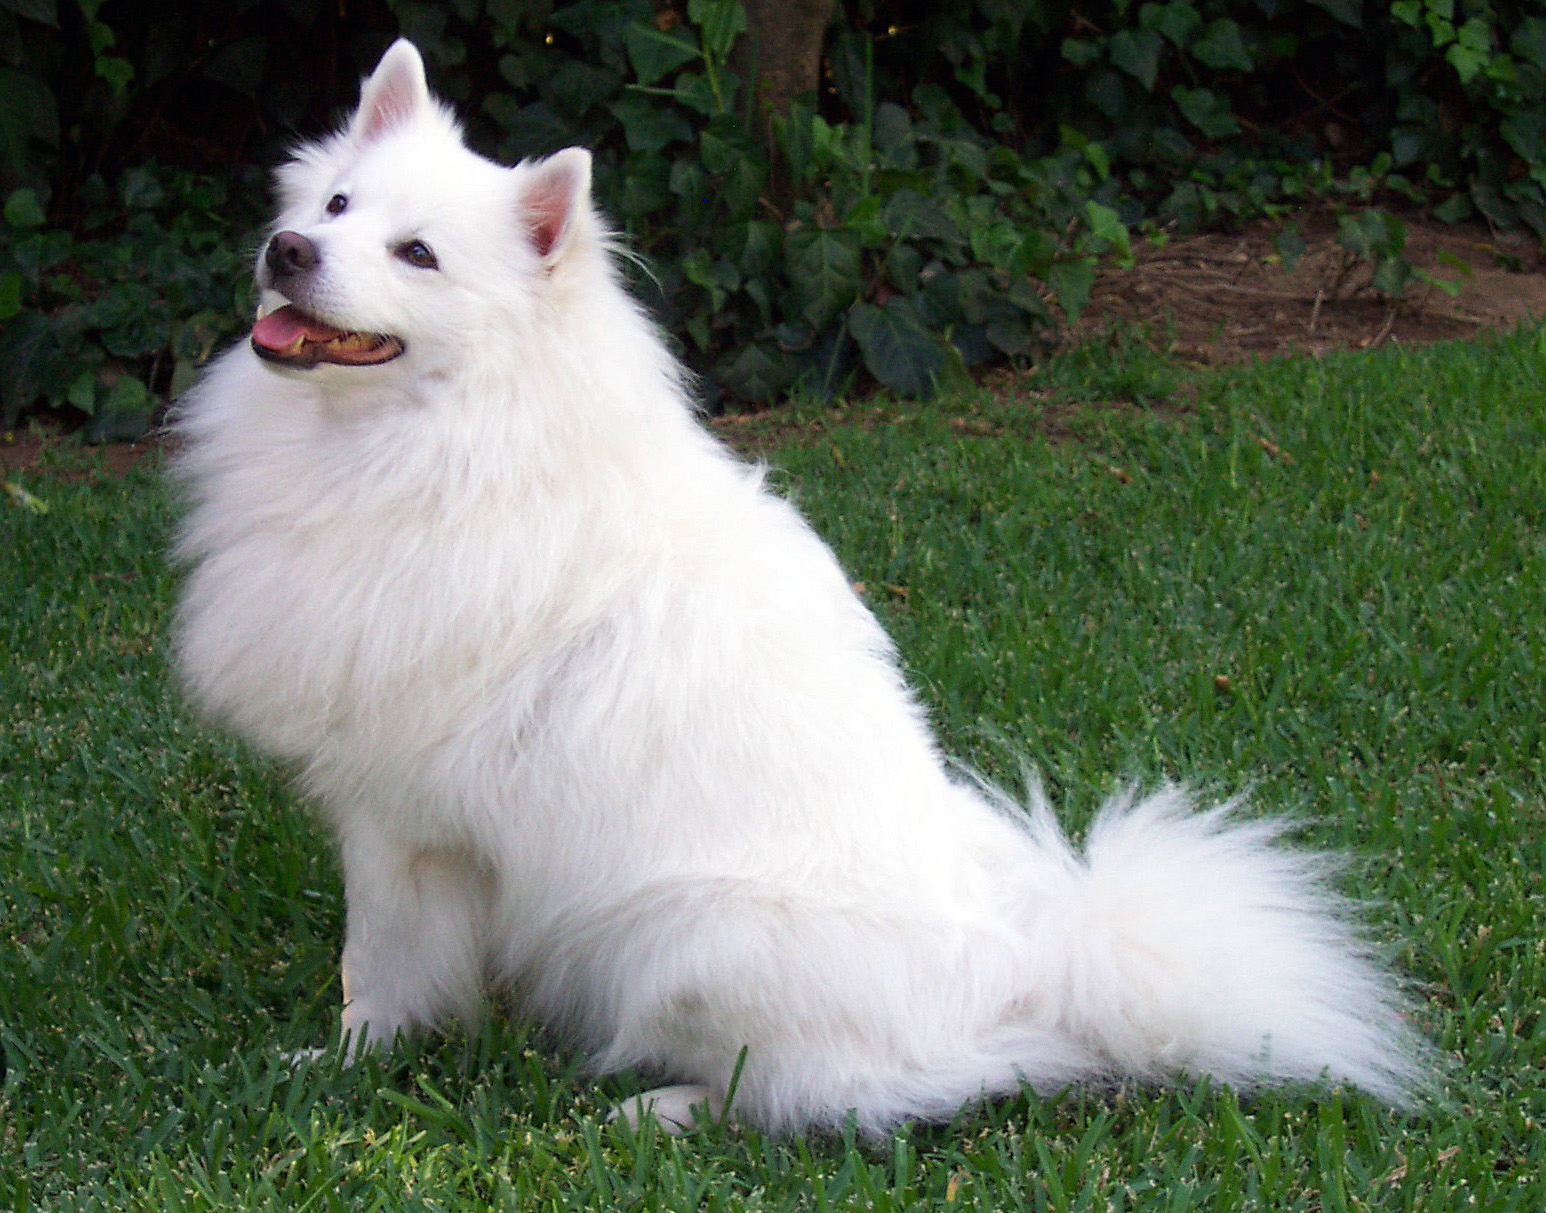

In [13]:
ShowImage(filename=dog_filename_1)

## Get last layer 1000 classes vector

In [36]:
def get_last_layer_probs(filename):
  input_image = Image.open(filename)
  preprocess = transforms.Compose([
      transforms.Resize(256),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])
  input_tensor = preprocess(input_image)
  input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

  # move the input and model to GPU for speed if available
  if torch.cuda.is_available():
      input_batch = input_batch.to('cuda')
      model.to('cuda')

  with torch.no_grad():
      output = model(input_batch)
  # Tensor of shape 1000, with confidence scores over ImageNet's 1000 classes
  #print(output[0])
  # The output has unnormalized scores. To get probabilities, you can run a softmax on it.
  probabilities = torch.nn.functional.softmax(output[0], dim=0)
  #print(probabilities)
  return output, probabilities

## Download 1000 image categories

In [9]:
# Download ImageNet labels
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2024-01-07 22:53:54--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2024-01-07 22:53:54 (103 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [10]:
# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

## Process first Dog image

In [37]:
dog_1_output, dog_1_probabilities = get_last_layer_probs(dog_filename_1)

# Show top categories per image
top5_prob, top5_catid = torch.topk(dog_1_probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

Samoyed 0.9494081735610962
Eskimo dog 0.01686004176735878
white wolf 0.013431272469460964
Pomeranian 0.006712892092764378
Siberian husky 0.002340118633583188


## pomeranian Dog!

In [18]:
# pomeranian

url2, dog_filename_2 = ("https://images.ctfassets.net/440y9b545yd9/2jHDansVxoiPKbICKz3Zai/30f121351698c62e088a4b5157b7e5af/Pomeranian850.jpg", "pomeranian.jpg")
try: urllib.URLopener().retrieve(url2, dog_filename_2)
except: urllib.request.urlretrieve(url2, dog_filename_2)

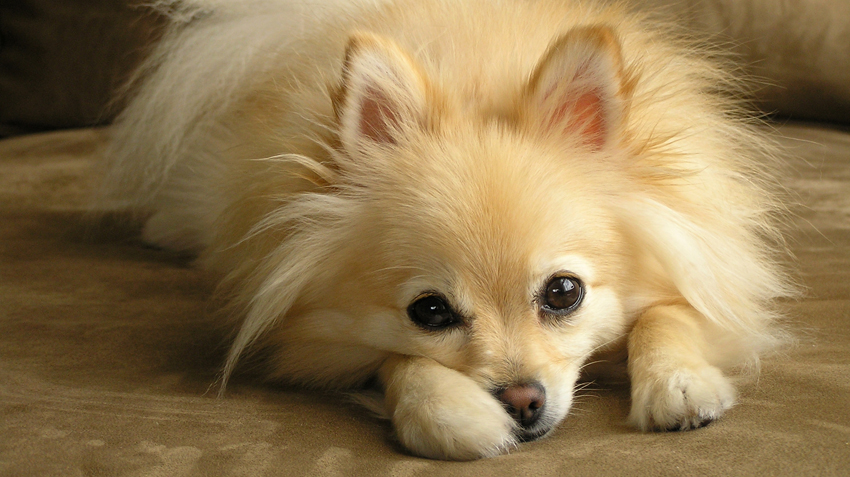

In [21]:
ShowImage(filename=dog_filename_2)

In [54]:
dog_2_output, dog_2_probabilities = get_last_layer_probs(dog_filename_2)

# Show top categories per image
top5_prob2, top5_catid2 = torch.topk(dog_2_probabilities, 5)
for i in range(top5_prob2.size(0)):
    print(categories[top5_catid2[i]], top5_prob2[i].item())

Pomeranian 0.936519980430603
Chihuahua 0.06131473928689957
papillon 0.0015972384717315435
Pekinese 0.00018076424021273851
tennis ball 0.00011881010141223669


## Cat Image

In [22]:
# cat

url3, cat_filename_1 = ("https://static01.nyt.com/images/2021/09/14/science/07CAT-STRIPES/07CAT-STRIPES-superJumbo.jpg", "cat.jpg")
try: urllib.URLopener().retrieve(url3, cat_filename_1)
except: urllib.request.urlretrieve(url3, cat_filename_1)

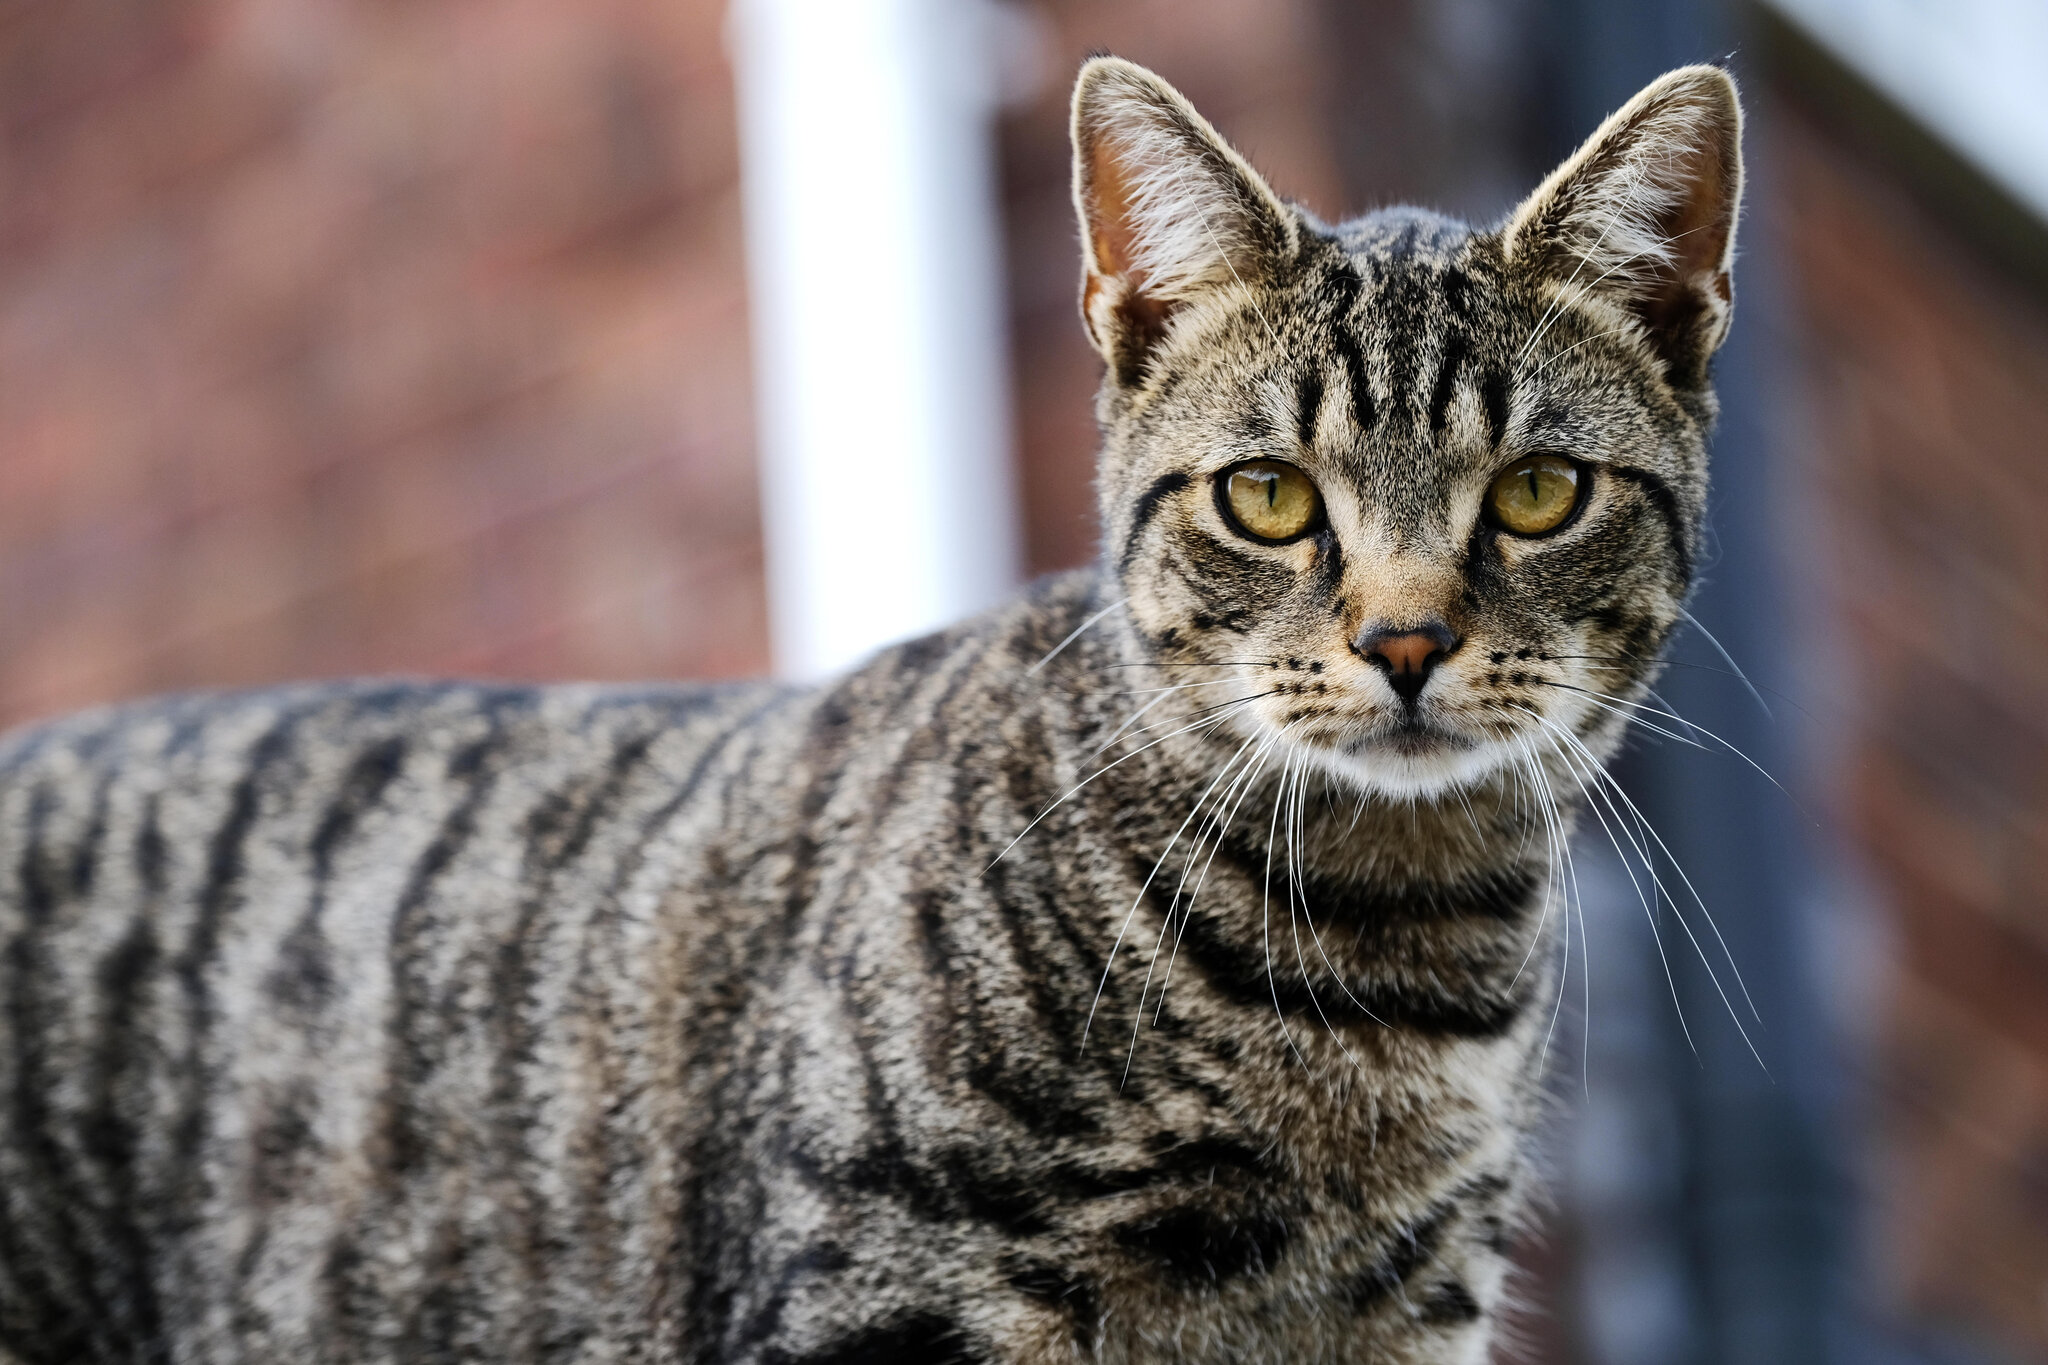

In [23]:
ShowImage(filename=cat_filename_1)

In [55]:
cat_1_output, cat_1_probabilities = get_last_layer_probs(cat_filename_1)

# Show top categories per image
top5_prob3, top5_catid3 = torch.topk(cat_1_probabilities, 5)
for i in range(top5_prob3.size(0)):
    print(categories[top5_catid3[i]], top5_prob3[i].item())

tiger cat 0.8319488167762756
tabby 0.14467309415340424
Egyptian cat 0.022403761744499207
tiger 0.0006488780491054058
radiator 0.0001264127204194665


## Street image

In [134]:
# street
url4, street_filename_1 = ("https://www.brandeis.edu/global/student-insights/images/moody-banner.jpg", "street.jpg")
try: urllib.URLopener().retrieve(url4, street_filename_1)
except: urllib.request.urlretrieve(url4, street_filename_1)

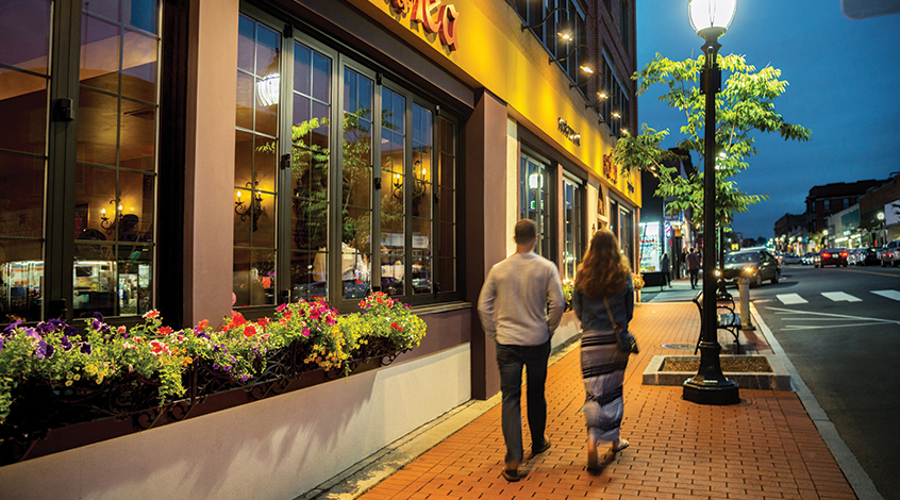

In [69]:
ShowImage(filename=street_filename_1)

In [70]:
street_1_output, street_1_probabilities = get_last_layer_probs(street_filename_1)

# Show top categories per image
top5_prob4, top5_catid4 = torch.topk(street_1_probabilities, 5)
for i in range(top5_prob4.size(0)):
    print(categories[top5_catid4[i]], top5_prob4[i].item())

greenhouse 0.2096439152956009
sliding door 0.15423746407032013
bakery 0.11304447799921036
restaurant 0.05363350734114647
doormat 0.05177750438451767


## Street view 2

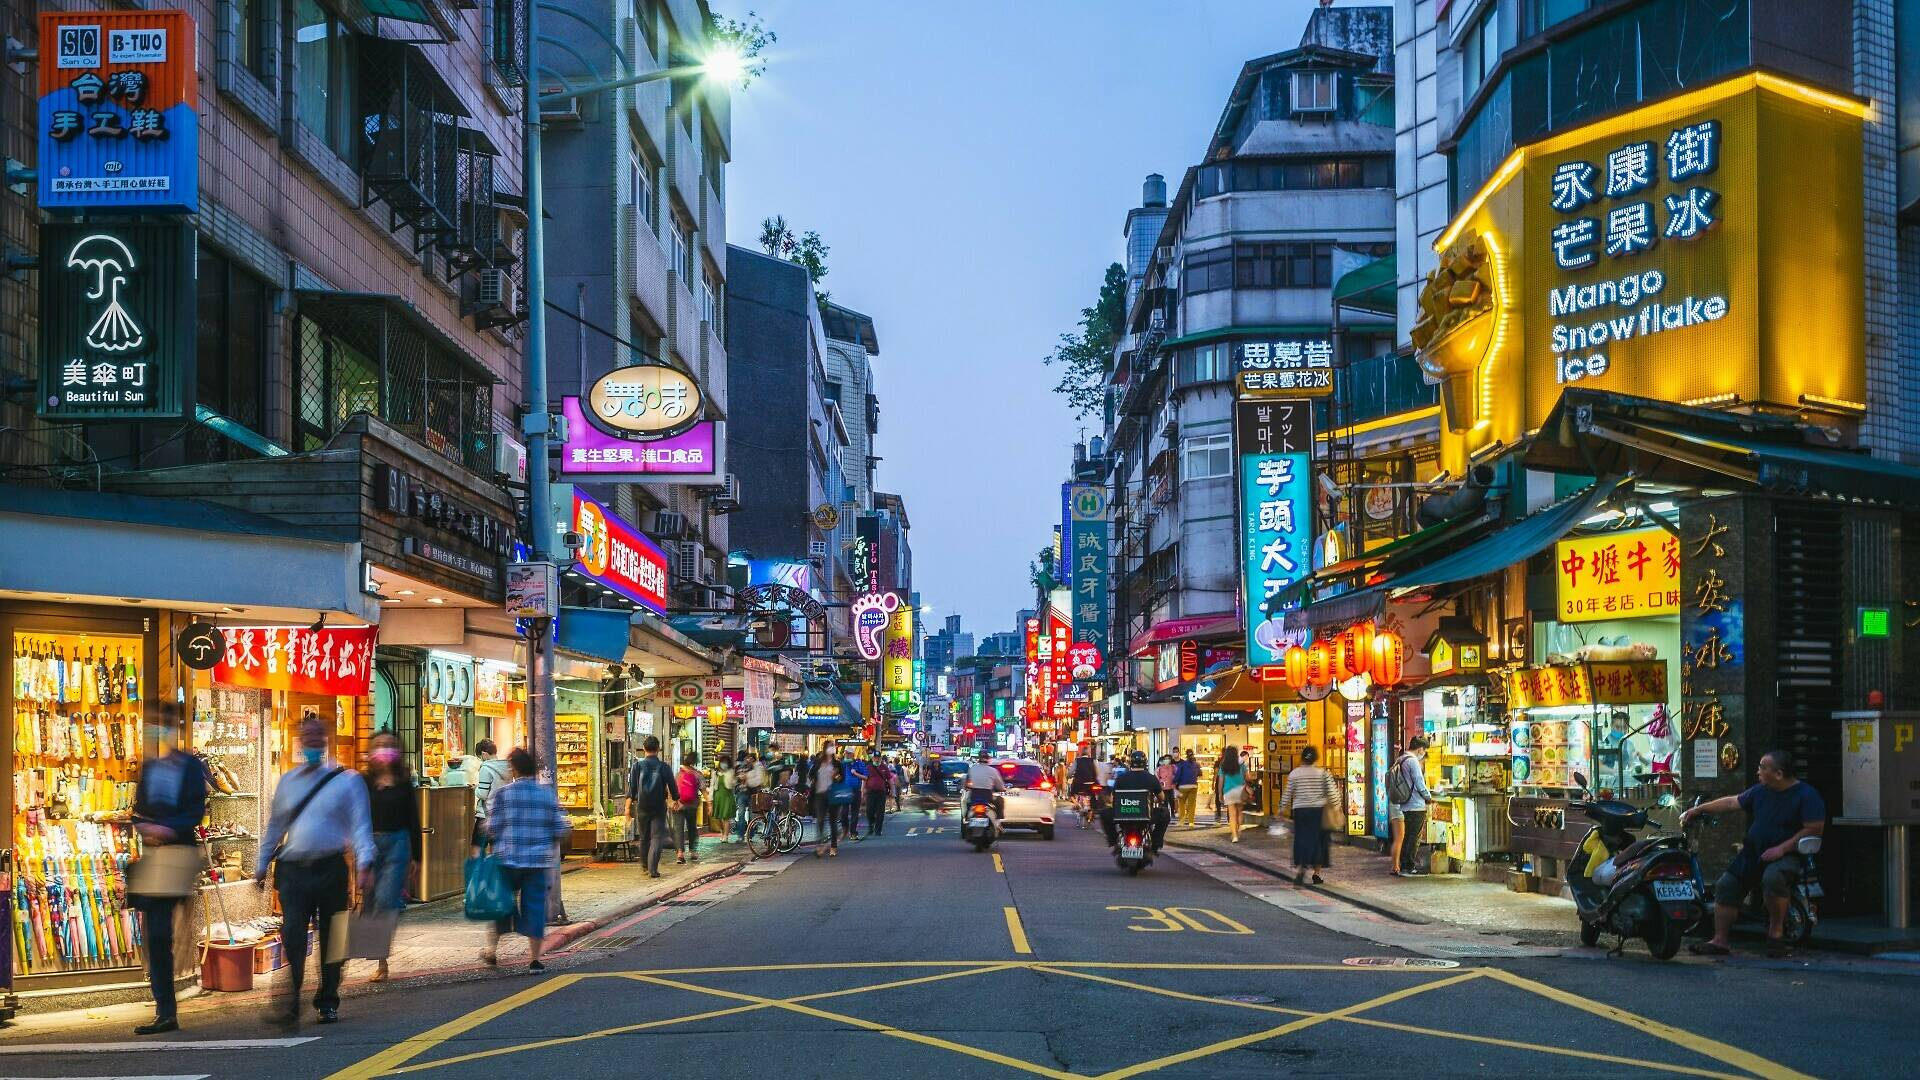

In [133]:
# street
url, street_filename_2 = ("https://media.timeout.com/images/105921973/1920/1080/image.jpg", "street.jpg")
try: urllib.URLopener().retrieve(url, street_filename_2)
except: urllib.request.urlretrieve(url, street_filename_2)
ShowImage(filename=street_filename_2)

In [72]:
street_2_output, street_2_probabilities = get_last_layer_probs(street_filename_2)

# Show top categories per image
top5_prob, top5_catid = torch.topk(street_2_probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

cab 0.24848535656929016
cinema 0.15924400091171265
traffic light 0.12469034641981125
toyshop 0.1180589571595192
street sign 0.09337789565324783


## Polo shirt 1 Red

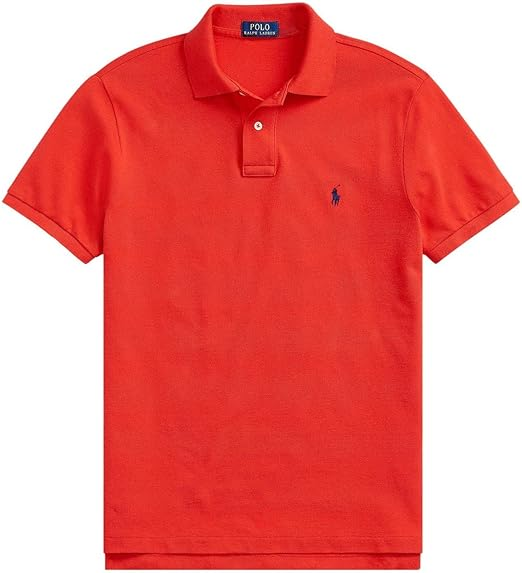

In [31]:
url, polo_filename_1 = ("https://m.media-amazon.com/images/I/81vVH7EIk4L._AC_SX522_.jpg", "polo1.jpg")
try: urllib.URLopener().retrieve(url, polo_filename_1)
except: urllib.request.urlretrieve(url, polo_filename_1)

ShowImage(filename=polo_filename_1)

In [58]:
# polo 1
polo_shirt_1_output, polo_shirt_1_probabilities = get_last_layer_probs(polo_filename_1)

# Show top categories per image
top5_prob, top5_catid = torch.topk(polo_shirt_1_probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())


jersey 0.8475652933120728
sweatshirt 0.1488044708967209
wool 0.0012125669745728374
pajama 0.0007559599471278489
velvet 0.0005006936262361705


## Polo shirt 2

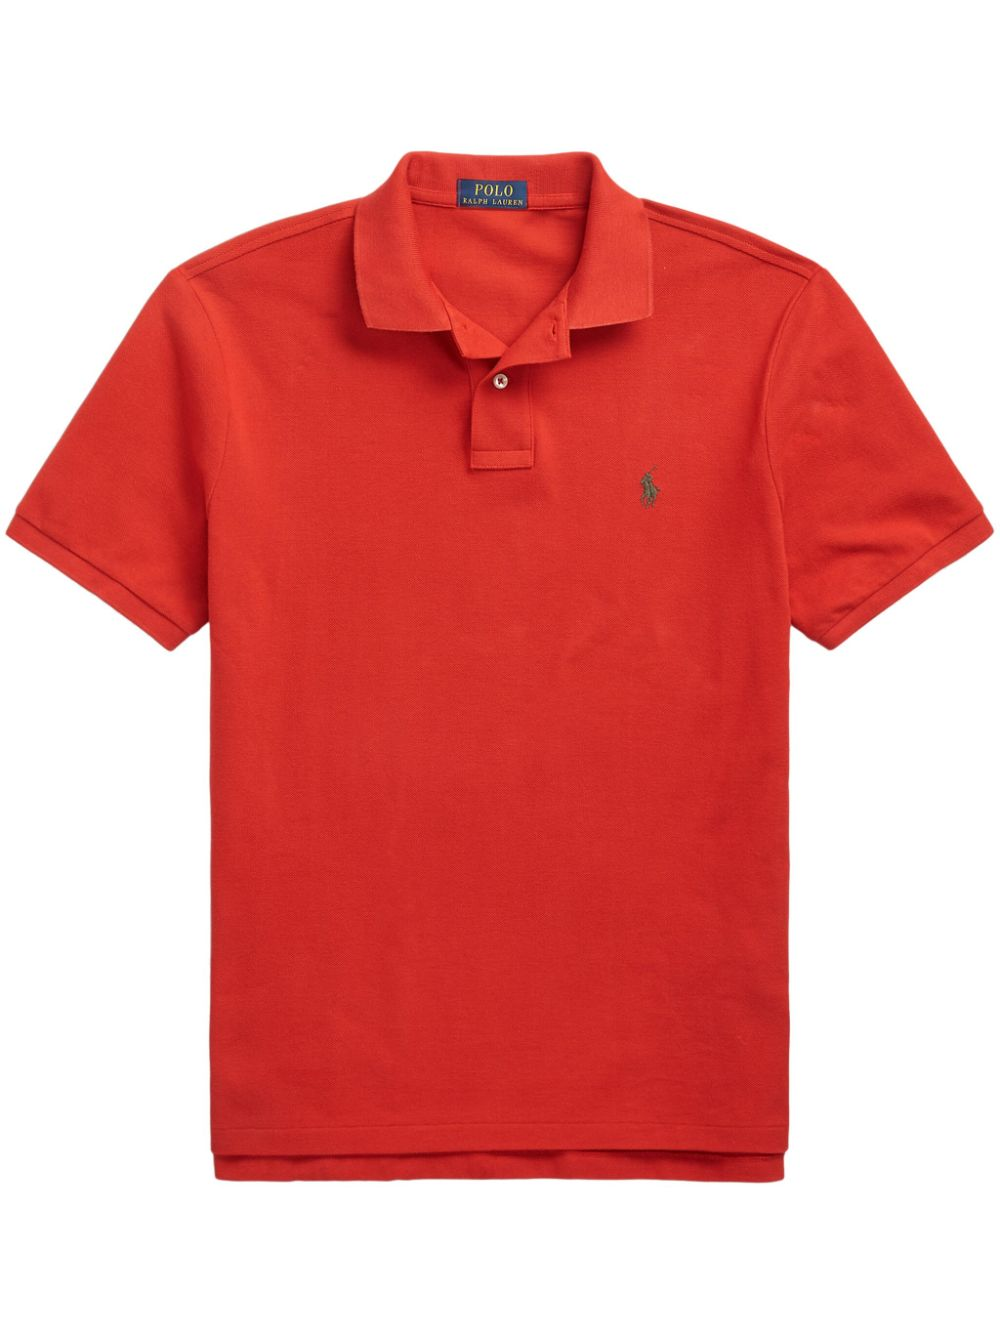

In [34]:
# polo 2

url, polo_filename_2 = ("https://cdn-images.farfetch-contents.com/20/51/20/17/20512017_50905017_1000.jpg", "polo2.jpg")
try: urllib.URLopener().retrieve(url, polo_filename_2)
except: urllib.request.urlretrieve(url, polo_filename_2)

ShowImage(filename=polo_filename_2)

In [59]:
# polo 2
polo_shirt_2_output, polo_shirt_2_probabilities = get_last_layer_probs(polo_filename_2)

# Show top categories per image
top5_prob, top5_catid = torch.topk(polo_shirt_2_probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())


jersey 0.8317726850509644
sweatshirt 0.15475544333457947
wool 0.005471899639815092
pajama 0.002275319304317236
velvet 0.001330086262896657


## Let's leverage output layer before softmax!

`Tensor of shape 1000, with confidence scores over ImageNet's 1000 classes`

`The output has unnormalized scores. To get probabilities, you can run a softmax on it.`

polo_shirt_1_output

In [44]:
type(dog_1_output[0])

torch.Tensor

In [73]:
# Get output layers for above images
dog1 = dog_1_output[0].cpu().detach().numpy()
dog2 = dog_2_output[0].cpu().detach().numpy()
cat1 = cat_1_output[0].cpu().detach().numpy()
street1 = street_1_output[0].cpu().detach().numpy()
street2 = street_2_output[0].cpu().detach().numpy()
thsirt1 = polo_shirt_1_output[0].cpu().detach().numpy()
thsirt2 = polo_shirt_2_output[0].cpu().detach().numpy()

In [61]:
cos_sim = dot(dog1, cat1)/(norm(dog1)*norm(cat1))
print("Dog 1 & Cat cosine sim: {}".format(cos_sim))

Dog 1 & Cat cosine sim: 0.20195600390434265


In [62]:
cos_sim = dot(dog2, cat1)/(norm(dog2)*norm(cat1))
print("Dog 2 & Cat cosine sim: {}".format(cos_sim))

Dog 2 & Cat cosine sim: 0.2752096951007843


In [63]:
cos_sim = dot(dog1, dog2)/(norm(dog1)*norm(dog2))
print("Dog 1 & Dog 2 cosine sim: {}".format(cos_sim))

Dog 1 & Dog 2 cosine sim: 0.75449538230896


In [74]:
cos_sim = dot(dog1, street1)/(norm(dog1)*norm(street1))
print("Dog 1 & Street 1 cosine sim: {}".format(cos_sim))

Dog 1 & Street 1 cosine sim: 0.3032916486263275


In [75]:
cos_sim = dot(dog1, street2)/(norm(dog1)*norm(street2))
print("Dog 1 & Street 2 cosine sim: {}".format(cos_sim))

Dog 1 & Street 2 cosine sim: 0.1416969746351242


In [76]:
cos_sim = dot(street1, street2)/(norm(street1)*norm(street2))
print("Street 1 & Street 2 cosine sim: {}".format(cos_sim))

Street 1 & Street 2 cosine sim: 0.655877947807312


In [77]:
cos_sim = dot(dog1, thsirt1)/(norm(dog1)*norm(thsirt1))
print("Dog 1 & Tshirt 1 cosine sim: {}".format(cos_sim))

Dog 1 & Tshirt 1 cosine sim: 0.21237903833389282


In [78]:
cos_sim = dot(dog1, thsirt2)/(norm(dog1)*norm(thsirt2))
print("Dog 1 & Tshirt 2 cosine sim: {}".format(cos_sim))

Dog 1 & Tshirt 2 cosine sim: 0.218189999461174


In [79]:
cos_sim = dot(thsirt1, thsirt2)/(norm(thsirt1)*norm(thsirt2))
print("Tshirt 1 & Tshirt 2 cosine sim: {}".format(cos_sim))

Tshirt 1 & Tshirt 2 cosine sim: 0.9844314455986023


In [81]:
a = polo_shirt_1_probabilities.cpu().detach().numpy()
b = polo_shirt_2_probabilities.cpu().detach().numpy()
cos_sim = dot(a, b)/(norm(a)*norm(b))
print("Tshirt 1 & Tshirt 2 cosine sim: {}".format(cos_sim))

Tshirt 1 & Tshirt 2 cosine sim: 0.9999323487281799


### Model Description

Here we have implementations for the models proposed in [Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556),
for each configurations and their with batchnorm version.

For example, configuration `A` presented in the paper is `vgg11`, configuration `B` is `vgg13`, configuration `D` is `vgg16`
and configuration `E` is `vgg19`. Their batchnorm version are suffixed with `_bn`.

Their Top-1 error rates on ImageNet dataset with pretrained models are listed below.

| Model structure | Top-1 error | Top-5 error |
| --------------- | ----------- | ----------- |
|  vgg11          | 30.98       | 11.37       |
|  vgg11_bn       | 26.70       | 8.58        |
|  vgg13          | 30.07       | 10.75       |
|  vgg13_bn       | 28.45       | 9.63        |
|  vgg16          | 28.41       | 9.62        |
|  vgg16_bn       | 26.63       | 8.50        |
|  vgg19          | 27.62       | 9.12        |
|  vgg19_bn       | 25.76       | 8.15        |

### References

- [Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556).

## What about the last FC layer


`Sequential(`

`  (0): Linear(in_features=25088, out_features=4096, bias=True)`

`  (1): ReLU(inplace=True)`

`  (2): Dropout(p=0.5, inplace=False)`

`  (3): Linear(in_features=4096, out_features=4096, bias=True)`

`  (4): ReLU(inplace=True)`

`  (5): Dropout(p=0.5, inplace=False)`

`  (6): Linear(in_features=4096, out_features=1000, bias=True)`

`)`

Chat GPT code:

import torch
from torchvision import transforms
from PIL import Image

# Load the pre-trained VGG19 model with batch normalization
model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg19_bn', pretrained=True)

# Define the transformation for the input image
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to fit VGG input size
    transforms.ToTensor(),           # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize
])

# Load and preprocess the image
image_path = 'path/to/your/image.jpg'
image = Image.open(image_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Set the model to evaluation mode
model.eval()

# Forward pass to get the output tensor before the ReLU activation
with torch.no_grad():
    output = model.features(input_tensor)  # Pass through feature extractor
    output = model.avgpool(output)
    output = torch.flatten(output, 1)  # Flatten the output for the fully connected layers
    output_before_relu = model.classifier[0](output)  # Access the first linear layer
    output_before_relu = model.classifier[1](output_before_relu)  # Apply ReLU activation

# Print the shape of the output tensor
print("Output after the first linear layer but before ReLU shape:", output_before_relu.shape)

# Access the values of the output tensor
output_values = output_before_relu.numpy()
print("Output after the first linear layer but before ReLU values:", output_values)


In this code, I have modified the index to model.classifier[0] to access the first linear layer and applied ReLU activation separately using model.classifier[1]. This should resolve the matrix multiplication error. I appreciate your understanding and persistence.








In [117]:
def get_output_before_relu(filename):
  # import torch
  # from torchvision import transforms
  # from PIL import Image

  # # Load the pre-trained VGG19 model with batch normalization
  # model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg19_bn', pretrained=True)

  # Define the transformation for the input image
  transform = transforms.Compose([
      transforms.Resize((224, 224)),  # Resize the image to fit VGG input size
      transforms.ToTensor(),           # Convert PIL Image to PyTorch Tensor
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize
  ])

  # Load and preprocess the image
  #
  image = Image.open(filename).convert('RGB')
  input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

  # Set the model to evaluation mode
  model.eval()

  # Forward pass to get the output tensor before the ReLU activation
  with torch.no_grad():
      output = model.features(input_tensor)  # Pass through feature extractor
      output = model.avgpool(output)
      output = torch.flatten(output, 1)  # Flatten the output for the fully connected layers
      output_before_relu = model.classifier[0](output)  # Access the first linear layer
      output_before_relu = model.classifier[1](output_before_relu)  # Apply ReLU activation



  # Print the shape of the output tensor
  print("Output before ReLU shape:", output_before_relu.shape)
  # Access the values of the output tensor
  output_values = output_before_relu
  #print("Output after the first linear layer but before ReLU values:", output_values)
  return output_values

In [131]:
polo_v1_fc = get_output_before_relu(polo_filename_1)
polo_v1_fc = polo_v1_fc.cpu().detach().numpy().reshape((4096, 1))

polo_v2_fc = get_output_before_relu(polo_filename_2)
polo_v2_fc = polo_v2_fc.cpu().detach().numpy().reshape((4096, 1))

a = np.squeeze(np.asarray(polo_v1_fc))

b = np.squeeze(np.asarray(polo_v2_fc))

cos_sim = dot(a, b)/(norm(a)*norm(b))
print("Tshirt 1 & Tshirt 2 cosine sim: {}".format(cos_sim))

Output before ReLU shape: torch.Size([1, 4096])
Output before ReLU shape: torch.Size([1, 4096])
Tshirt 1 & Tshirt 2 cosine sim: 0.9385613203048706


In [135]:
s1_fc = get_output_before_relu(street_filename_1)
s1_fc = s1_fc.cpu().detach().numpy().reshape((4096, 1))

s2_fc = get_output_before_relu(street_filename_2)
s2_fc = s2_fc.cpu().detach().numpy().reshape((4096, 1))

a = np.squeeze(np.asarray(s1_fc))

b = np.squeeze(np.asarray(s2_fc))

cos_sim = dot(a, b)/(norm(a)*norm(b))
print("Street 1 & Street 2 cosine sim: {}".format(cos_sim))

Output before ReLU shape: torch.Size([1, 4096])
Output before ReLU shape: torch.Size([1, 4096])
Street 1 & Street 2 cosine sim: 1.0


In [ ]:
s1_fc = get_output_before_relu(street_filename_1)
s1_fc = s1_fc.cpu().detach().numpy().reshape((4096, 1))

s2_fc = get_output_before_relu(street_filename_2)
s2_fc = s2_fc.cpu().detach().numpy().reshape((4096, 1))

a = np.squeeze(np.asarray(s1_fc))

b = np.squeeze(np.asarray(s2_fc))

cos_sim = dot(a, b)/(norm(a)*norm(b))
print("Street 1 & Street 2 cosine sim: {}".format(cos_sim))